In [9]:
# %pip install kagglehub pandas matplotlib numpy scikit-learn seaborn

In [1]:
import kagglehub
import pandas as pd

# Load the dataset
df_path = kagglehub.dataset_download("itsmrmallik/tf-countries", path="mexico_soc_dataset.csv")
df = pd.read_csv(df_path)

# Display the first 5 rows
pd.set_option('display.max_columns', None)
df.head()

d:\tierra\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,date,elcosp,landcover,latitude,longitude,lower_depth,orgc,phaq,precipitation,sand,temperature,upper_depth,ecoregion,rock_fragments,silt_plus_clay,depth_fraction,soc_tha
0,10/10/2003,0.2,9,28.508804,-106.698715,8,2.0,9.1,113.945740,100.0,15.176553,0,5,13.175046,0.0,1.000000,-3.440960
1,4/13/2005,0.1,17,27.462610,-114.098600,20,1.0,8.4,83.411194,86.0,16.085426,0,5,4.552547,14.0,1.000000,-0.538765
2,4/15/2005,0.2,17,27.798883,-114.151680,6,2.0,8.4,83.411194,82.0,16.085426,0,5,1.959367,18.0,0.115385,-0.031285
3,5/29/2004,0.0,2,17.367722,-93.185150,14,1.0,5.5,147.141876,98.0,16.675776,0,1,1.040600,2.0,1.000000,-0.006157
4,8/6/2003,0.1,7,30.903263,-111.515000,18,1.0,7.8,155.092468,88.0,16.817062,0,5,27.627751,12.0,1.000000,-4.038258


In [2]:
TARGET = 'orgc' # Target column

In [ ]:
import geopandas as gpd
import libpysal as lps
import esda
from sklearn.neighbors import NearestNeighbors

# convert to geodataframe
gdf = gpd.GeoDataFrame(df, crs="EPSG:3857", geometry=gpd.points_from_xy(df.longitude, df.latitude))
# gdf = gdf.to_crs(epsg=3857)  # Convert to a projected CRS (meters) for distance calculations

# y as target
y = gdf[TARGET]

# KNN weights
k = 5
wknn = lps.weights.KNN.from_dataframe(gdf, k=k)
wknn.transform = 'r'
gdf['spatial_lag_knn'] = lps.weights.lag_spatial(wknn, y)

# Local moran's I
lisa = esda.Moran_Local(y, wknn)
gdf['moran_i'] = lisa.Is  # This assigns unique Moran's I value for each location

# Compute KNN-based Average Distance
nbrs = NearestNeighbors(n_neighbors=k, algorithm='ball_tree').fit(gdf.geometry.apply(lambda p: (p.x, p.y)).tolist())
distances, _ = nbrs.kneighbors(gdf.geometry.apply(lambda p: (p.x, p.y)).tolist())
gdf["avg_knn_distance"] = distances[:, 1:].mean(axis=1)  # Exclude self-distance (0)

### 5. Compute Point Density (Within 1km Radius) ###
radius = 1000  # 1 km
distance_band_weights = lps.weights.DistanceBand.from_dataframe(gdf, threshold=radius, binary=True)
gdf["point_density"] = distance_band_weights.sparse.sum(axis=1).A1  # Count of neighbors within radius

# Find hotspot clusters and coldspot clusters
gdf['hotspot'] = 0
gdf['coldspot'] = 0
gdf.loc[(lisa.q==1) & (y > y.mean()), 'hotspot'] = 1
gdf.loc[(lisa.q==3) & (y < y.mean()), 'coldspot'] = 1

# save as geojson
gdf_geojson = "D:/tierra/data/mexico_soc_dataset.geojson"
gdf.to_file(gdf_geojson, driver='GeoJSON')

gdf.head()

d:\tierra\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


,date,elcosp,landcover,latitude,longitude,lower_depth,orgc,phaq,precipitation,sand,temperature,upper_depth,ecoregion,rock_fragments,silt_plus_clay,depth_fraction,soc_tha,geometry,spatial_lag_knn,moran_i,avg_knn_distance,point_density,hotspot,coldspot
0,10/10/2003,0.2,9,28.508804,-106.698715,8,2.0,9.1,113.945740,100.0,15.176553,0,5,13.175046,0.0,1.000000,-3.440960,POINT (-106.699 28.509),9.0,0.321926,0.217124,3002.0,0,1
1,4/13/2005,0.1,17,27.462610,-114.098600,20,1.0,8.4,83.411194,86.0,16.085426,0,5,4.552547,14.0,1.000000,-0.538765,POINT (-114.099 27.463),2.2,0.849161,0.157739,3002.0,0,1
2,4/15/2005,0.2,17,27.798883,-114.151680,6,2.0,8.4,83.411194,82.0,16.085426,0,5,1.959367,18.0,0.115385,-0.031285,POINT (-114.152 27.799),10.2,0.240636,0.132066,3001.0,0,1
3,5/29/2004,0.0,2,17.367722,-93.185150,14,1.0,5.5,147.141876,98.0,16.675776,0,1,1.040600,2.0,1.000000,-0.006157,POINT (-93.185 17.368),19.2,-0.400443,0.175282,3002.0,0,0
4,8/6/2003,0.1,7,30.903263,-111.515000,18,1.0,7.8,155.092468,88.0,16.817062,0,5,27.627751,12.0,1.000000,-4.038258,POINT (-111.515 30.903),4.6,0.672746,0.293641,3002.0,0,1


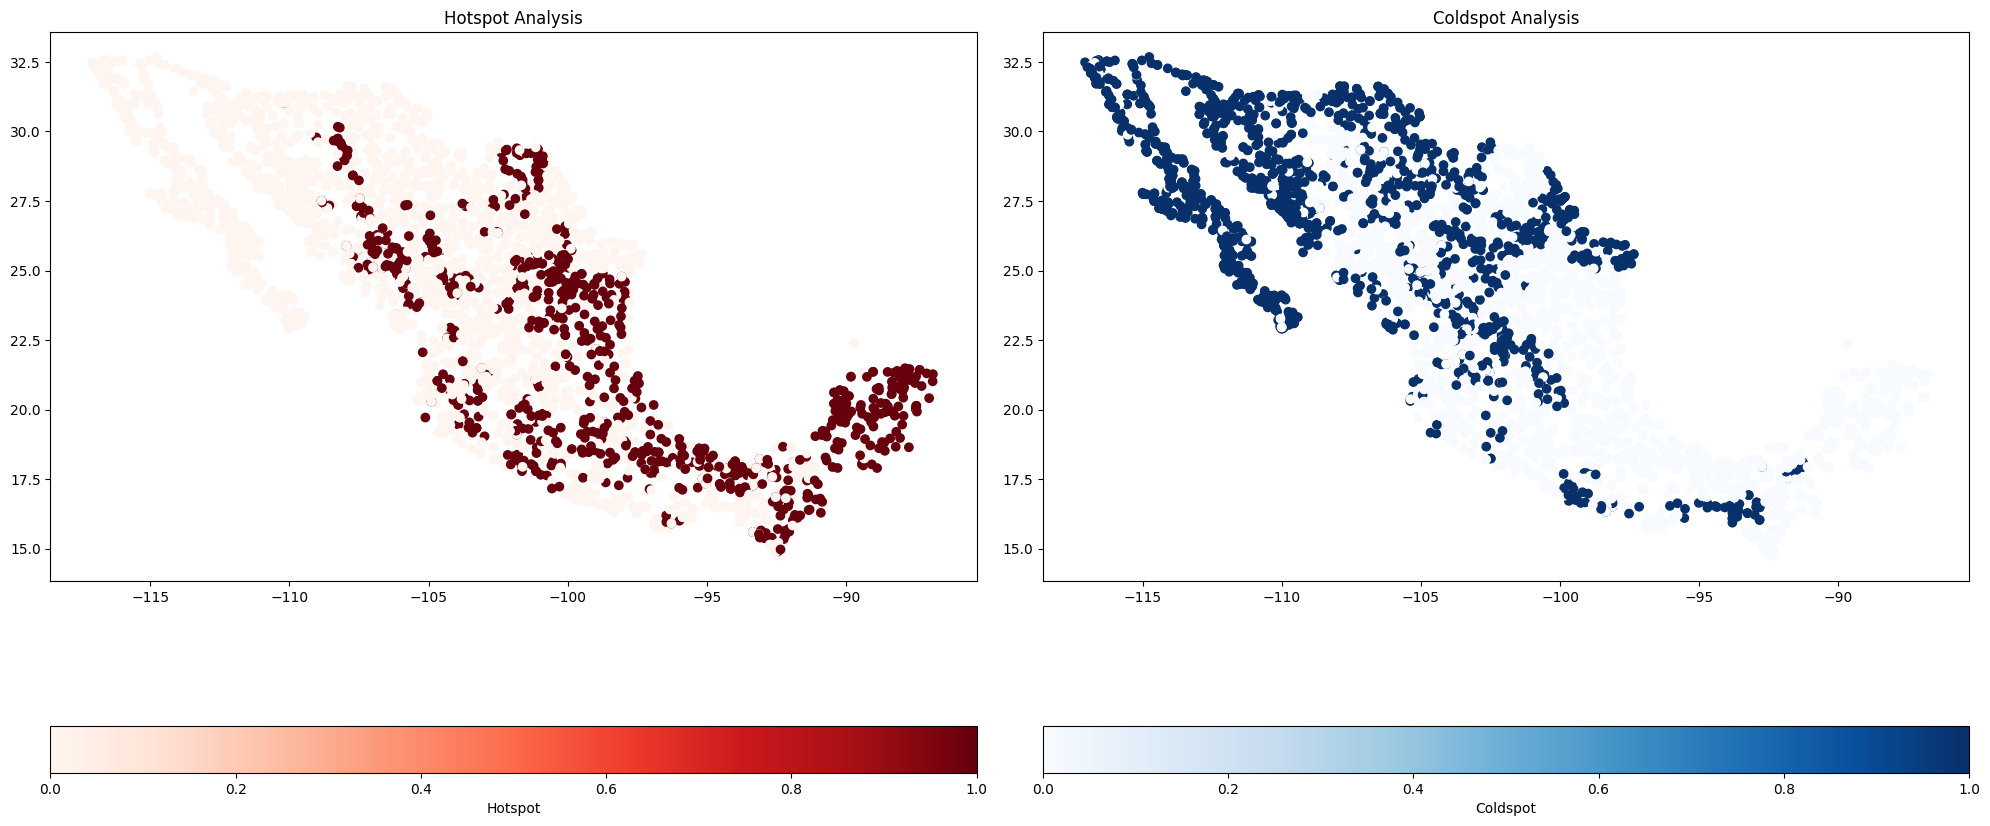

In [4]:
# Plot
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot hotspots
gdf.plot(column='hotspot', ax=ax1, legend=True, cmap='Reds', 
         legend_kwds={'label': "Hotspot", 'orientation': "horizontal"})
ax1.set_title("Hotspot Analysis")

# Plot coldspots
gdf.plot(column='coldspot', ax=ax2, legend=True, cmap='Blues',
         legend_kwds={'label': "Coldspot", 'orientation': "horizontal"})
ax2.set_title("Coldspot Analysis")

plt.tight_layout()
plt.show()

In [30]:
# Define columns to drop - use flat list instead of nested lists
COLUMNS_TO_DROP = ['date', 'latitude', 'longitude', 'geometry', 'soc_tha', 
                #    'hotspot', 'coldspot',
                #    'moran_i', 'spatial_lag_knn',
                   'depth_fraction', 'rock_fragments',
                   'upper_depth', 'lower_depth'
                   ]

CATEGORICAL = ['ecoregion', 'landcover'] # Categorical columns to be one-hot encoded

def preprocess(df):    
    # drop non useful columns if they exist
    columns_to_drop = [col for col in COLUMNS_TO_DROP if col in df.columns]
    df = df.drop(columns=columns_to_drop, errors='ignore')

    # drop missing values
    df = df.dropna()

    # one-hot encode categorical columns that exist
    categorical_cols = [col for col in CATEGORICAL if col in df.columns]
    if categorical_cols:
        df = pd.get_dummies(df, columns=categorical_cols, prefix=categorical_cols, prefix_sep="_", drop_first=True)

    # drop duplicates
    df = df.drop_duplicates()

    return df

# load geojson
gdf = gpd.read_file(gdf_geojson)

# preprocess
df = preprocess(gdf)

print(f"Shape of the dataset after preprocessing: {df.shape}")
print(f"Columns in the dataset after preprocessing: {df.columns}")
df.head()

Shape of the dataset after preprocessing: (3003, 33)
Columns in the dataset after preprocessing: Index(['elcosp', 'orgc', 'phaq', 'precipitation', 'sand', 'temperature',
       'silt_plus_clay', 'spatial_lag_knn', 'moran_i', 'avg_knn_distance',
       'point_density', 'hotspot', 'coldspot', 'ecoregion_2', 'ecoregion_3',
       'ecoregion_4', 'ecoregion_5', 'ecoregion_6', 'ecoregion_7',
       'landcover_2', 'landcover_4', 'landcover_5', 'landcover_6',
       'landcover_7', 'landcover_8', 'landcover_9', 'landcover_10',
       'landcover_11', 'landcover_12', 'landcover_13', 'landcover_14',
       'landcover_16', 'landcover_17'],
      dtype='object')


,elcosp,orgc,phaq,precipitation,sand,temperature,silt_plus_clay,spatial_lag_knn,moran_i,avg_knn_distance,point_density,hotspot,coldspot,ecoregion_2,ecoregion_3,ecoregion_4,ecoregion_5,ecoregion_6,ecoregion_7,landcover_2,landcover_4,landcover_5,landcover_6,landcover_7,landcover_8,landcover_9,landcover_10,landcover_11,landcover_12,landcover_13,landcover_14,landcover_16,landcover_17
0,0.2,2.0,9.1,113.945740,100.0,15.176553,0.0,9.0,0.321926,0.217124,3002.0,0,1,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1,0.1,1.0,8.4,83.411194,86.0,16.085426,14.0,2.2,0.849161,0.157739,3002.0,0,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,0.2,2.0,8.4,83.411194,82.0,16.085426,18.0,10.2,0.240636,0.132066,3001.0,0,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,0.0,1.0,5.5,147.141876,98.0,16.675776,2.0,19.2,-0.400443,0.175282,3002.0,0,0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
4,0.1,1.0,7.8,155.092468,88.0,16.817062,12.0,4.6,0.672746,0.293641,3002.0,0,1,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False


In [27]:
# %pip install xgboost keras tensorflow

Random Forest Metrics: {'MSE': 5.897291014975041, 'RMSE': 2.428433860531318, 'MAE': 0.8455074875207987, 'R2': 0.965817146103823}


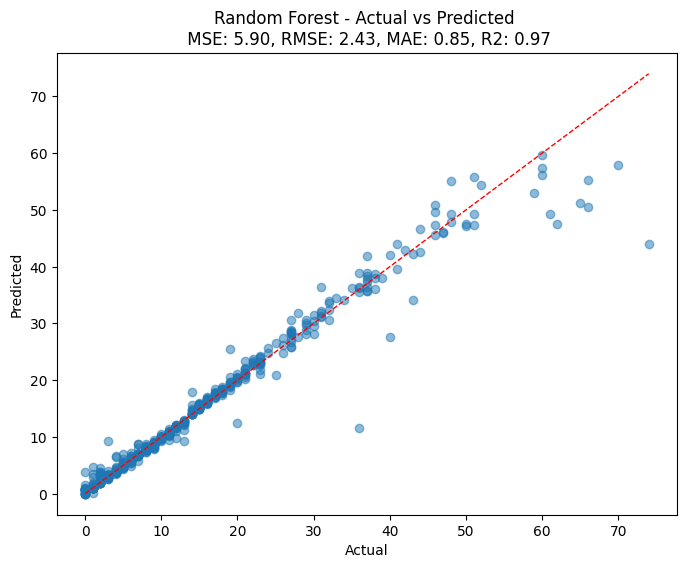

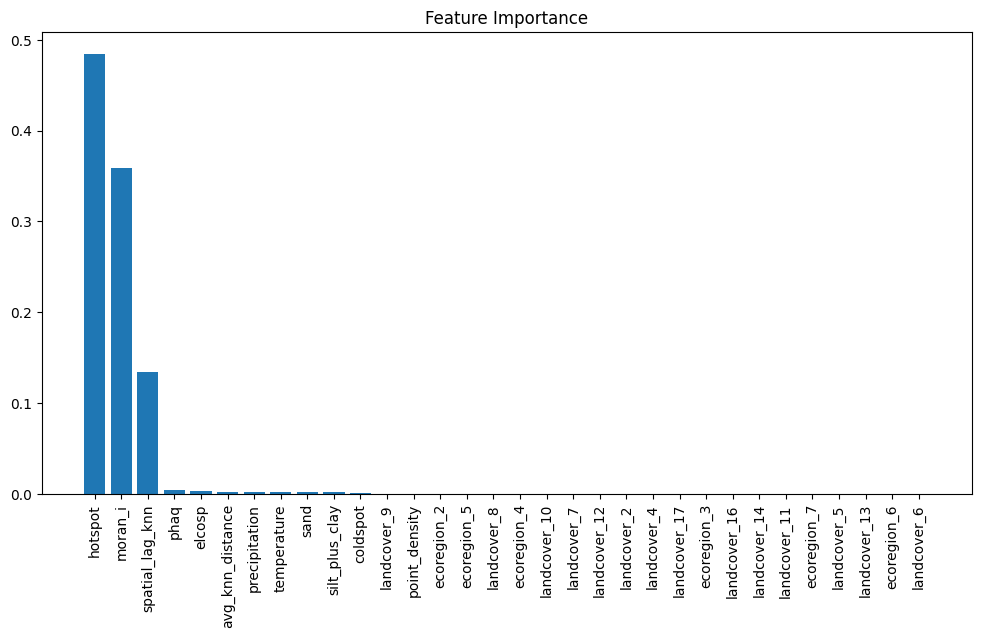

Gradient Boosting Metrics: {'MSE': 12.198665128182927, 'RMSE': 3.492658747742603, 'MAE': 2.1831481195858418, 'R2': 0.9292920788975458}


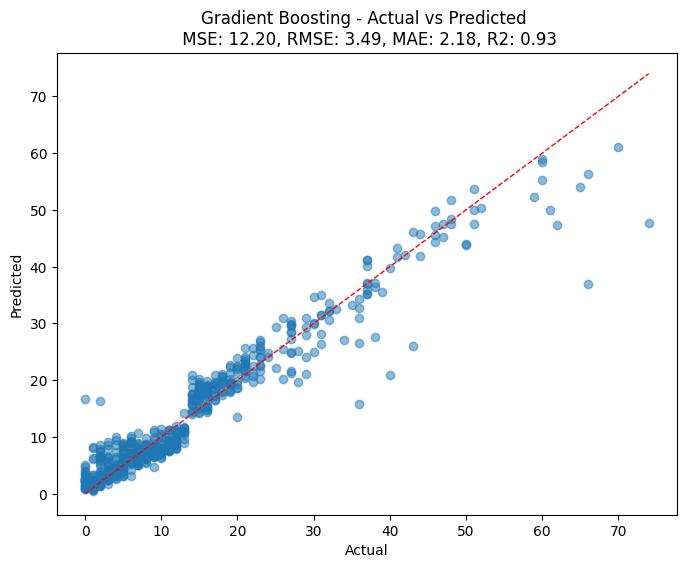

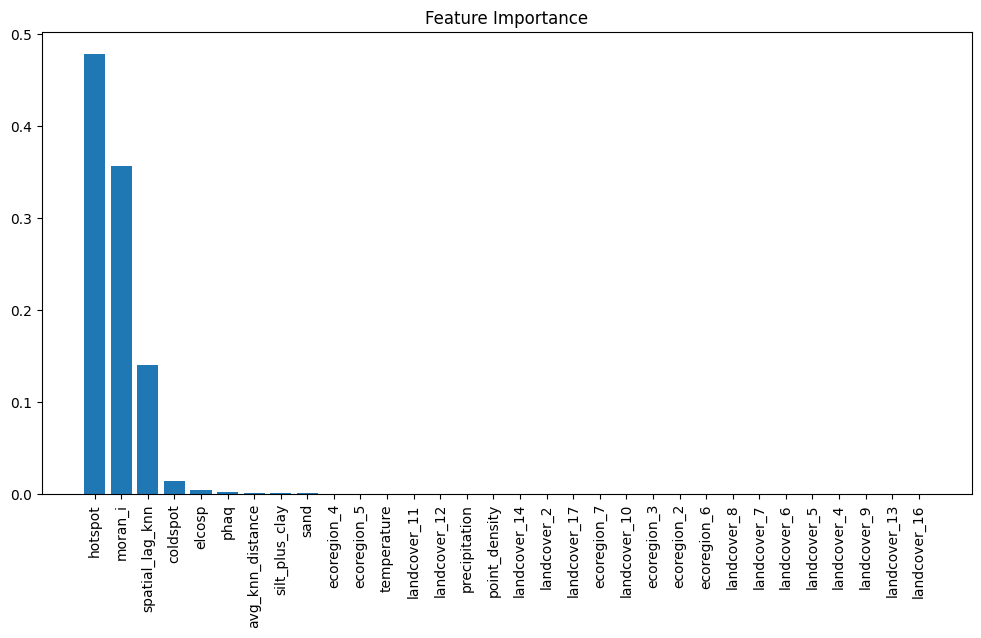

Neural Network Metrics: {'MSE': 20.565946944621423, 'RMSE': 4.534969343294552, 'MAE': 2.6266662094698234, 'R2': 0.8807922556544383}


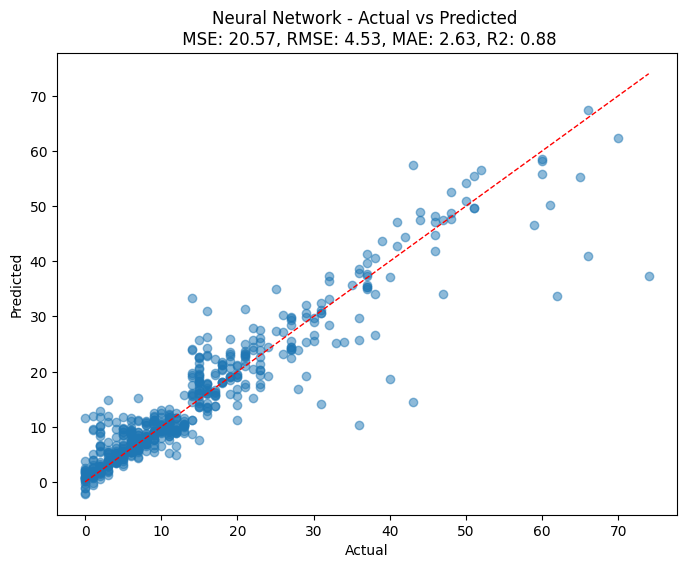

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

def plot_regression_line(y_test, y_pred, model_name, mse, rmse, mae, r2):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=1, ls='--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{model_name} - Actual vs Predicted \n MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}")
    plt.show()

# Split the dataset into features and target
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model
models_to_evaluate = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Neural Network": MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

for model_name, model in models_to_evaluate.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    metrics = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

    print(f"{model_name} Metrics: {metrics}")

    # Plot the predictions
    plot_regression_line(y_test, y_pred, model_name, mse, rmse, mae, r2)

    # plot feature importance
    if hasattr(model, 'feature_importances_'):
        feature_importance = model.feature_importances_
        feature_importance_df = pd.DataFrame(feature_importance, index=X.columns, columns=["Importance"])
        feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

        plt.figure(figsize=(12, 6))
        plt.bar(feature_importance_df.index, feature_importance_df["Importance"])
        plt.xticks(rotation=90)
        plt.title("Feature Importance")
        plt.show()
    

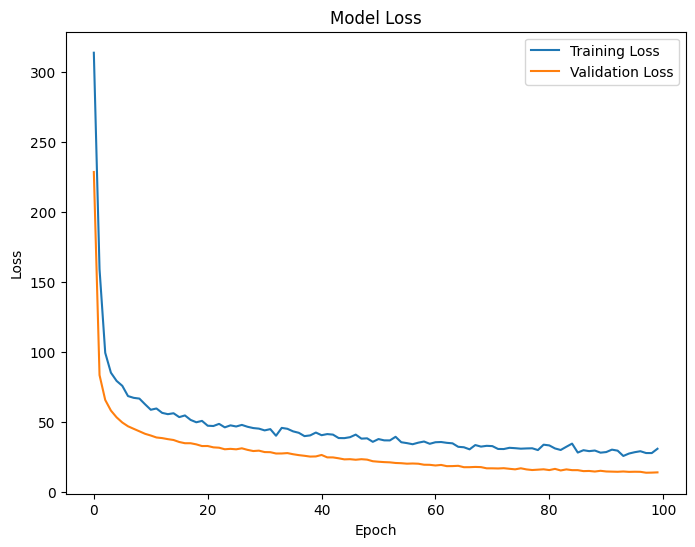

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Deep Learning Model - MSE: 19.462689752306105, RMSE: 4.4116538568099495, MAE: 2.6363030939847976, R2: 0.8871871375280066


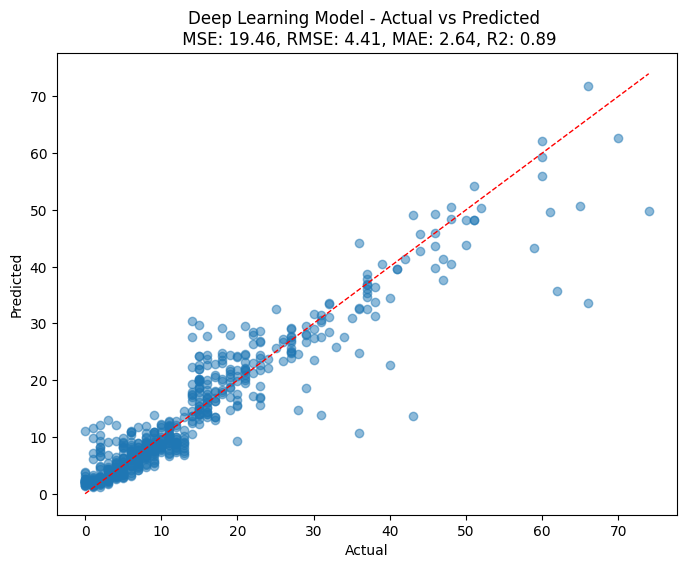

In [29]:
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout

def dl_model_one(X_train):
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation='relu'), # first hidden layer with 64 neurons
        Dropout(0.2), # add dropout to reduce overfitting
        Dense(32, activation='relu'), # second hidden layer with 32 neurons
        Dropout(0.2), # add dropout to reduce overfitting
        Dense(1) # output layer with 1 neuron
    ])    

    return model

# Train the deep learning model
model = dl_model_one(X_train_scaled)
model.compile(optimizer='adam', loss='mean_squared_error') # Compile the model

# Train the model with validation split
history = model.fit(X_train_scaled, y_train, 
                   epochs=100, 
                   batch_size=32, 
                   validation_split=0.2, 
                   verbose=0)

# Plot training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Evaluate the model
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Deep Learning Model - MSE: {mse}, RMSE: {rmse}, MAE: {mae}, R2: {r2}")

# Plot the predictions
plot_regression_line(y_test, y_pred, "Deep Learning Model", mse, rmse, mae, r2)